<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [2]:
# Your code here
college = pd.read_csv('./data/College.csv')
college

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [3]:
# Your code here
college.shape

(777, 19)

#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [18]:
# Your code here
# Convert a column to numeric, forcing errors to NaN
college['PhD'] = pd.to_numeric(
    college['PhD'], errors='coerce'
)

college[
    college['PhD'] > 100 
]

college = college[
    college['PhD'] <= 100 
]

college[
    college['PhD'] > 100 
]

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate


#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [22]:
# Your code here

college[
    college['Grad.Rate'] > 100 
]

college = college[
    college['Grad.Rate'] <= 100 
]

college[
    college['Grad.Rate'] > 100 
]

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate


In [26]:
college.columns

Index(['Unnamed: 0', 'Private', 'Apps', 'Accept', 'Enroll', 'Top10perc',
       'Top25perc', 'F.Undergrad', 'P.Undergrad', 'Outstate', 'Room.Board',
       'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 'perc.alumni',
       'Expend', 'Grad.Rate'],
      dtype='str')

## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [75]:
def skew_calc(df):
    """Diagnoses skewness for numeric columns and recommends transformations based on

    data constraints (strictly positive, zeros present, negative values).
    """
    numeric_df = df.select_dtypes(include="number")
    results = []

    for col in numeric_df.columns:
        # Skip binary or ID columns (2 or fewer unique values)
        if numeric_df[col].nunique() <= 2:
            continue

        val = numeric_df[col].skew()
        min_val = numeric_df[col].min()

        # Classify Degree and Direction
        if val < -1:
            degree, direction = "Highly", "Left"
        elif -1 <= val <= -0.5:
            degree, direction = "Moderately", "Left"
        elif -0.5 < val < 0.5:
            degree, direction = "Symmetrical", "None"
        elif 0.5 <= val <= 1:
            degree, direction = "Moderately", "Right"
        else:
            degree, direction = "Highly", "Right"

        # Recommend Transformation based on Decision Matrix
        if degree == "Symmetrical":
            rec_trans = "None"
        elif min_val < 0:
            # Contains negative values -> Yeo-Johnson
            rec_trans = "Yeo-Johnson"
        elif min_val == 0:
            # Contains zeros, but no negatives
            if degree == "Highly" and direction == "Right":
                rec_trans = "Log Plus One (log(x + 1))"
            else:
                rec_trans = "Yeo-Johnson"
        else:
            # Strictly positive (min_val > 0) -> Box-Cox
            rec_trans = "Box-Cox"

        results.append(
            {
                "Feature": col,
                "Skewness": round(val, 4),
                "Degree": degree,
                "Direction": direction,
                "Min_Value": min_val,
                "Recommended_Transformation": rec_trans,
            }
        )

    return pd.DataFrame(results)

In [76]:
skew_calc(college)

,Feature,Skewness,Degree,Direction,Min_Value,Recommended_Transformation
0,Apps,3.8002,Highly,Right,81.0,Box-Cox
1,Accept,3.4704,Highly,Right,72.0,Box-Cox
2,Enroll,2.6941,Highly,Right,35.0,Box-Cox
3,Top10perc,1.4079,Highly,Right,1.0,Box-Cox
4,Top25perc,0.2503,Symmetrical,None,9.0,None
5,F.Undergrad,2.6152,Highly,Right,139.0,Box-Cox
6,P.Undergrad,5.7017,Highly,Right,1.0,Box-Cox
7,Outstate,0.5133,Moderately,Right,2340.0,Box-Cox
8,Room.Board,0.4861,Symmetrical,None,1780.0,None
9,Books,3.4897,Highly,Right,96.0,Box-Cox


In [77]:
college

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70.0,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29.0,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53.0,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92.0,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76.0,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60.0,60,21.0,14,4469,40
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73.0,75,13.3,31,9189,83
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67.0,75,14.4,20,8323,49
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96.0,96,5.8,49,40386,99


In [ ]:
# Now import the function from myutils


In [84]:
def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after 
    distributions side by side with the skewness degree on each subplot.
    """
# Your code here
    num_rows= len(skew_table)
    normal_table = df.copy()
    for i in range(0, num_rows):
        row = skew_table.iloc[i]
        feature_name = row["Feature"]
        rec = row["Recommended_Transformation"]
        if rec == 'Log Plus One (log(x + 1))':
            normal_table[feature_name] = np.log1p(normal_table[feature_name])
        elif rec == 'Yeo-Johnson':
            pt_yeo= PowerTransformer(method = 'yeo-johnson')
            normal_table[feature_name] = pt_yeo.fit_transform(normal_table[[feature_name]])
        elif rec == 'Box-Cox':
            pt_boxcox= PowerTransformer(method = 'box-cox')
            normal_table[feature_name] = pt_boxcox.fit_transform(normal_table[[feature_name]])
        else:
            normal_table[feature_name] = normal_table[feature_name]
                                                              
             # ----------------- PLOTTING -----------------
        
        # 1. Calculate dynamic statistics
        orig_skew = df[feature_name].skew()
        trans_skew = normal_table[feature_name].skew()
        
        # 2. Initialize figure with custom background
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor="#F8F9FA")
        
        # --- Left Plot: Original Feature Distribution ---
        ax0 = axes[0]
        ax0.set_facecolor("#FFFFFF")
        sns.histplot(
            df[feature_name],
            ax=ax0,
            kde=True,
            color="#2B5C8F",  # Professional Deep Blue
            edgecolor="white",
            linewidth=0.8,
            stat="density",
            line_kws={"linewidth": 2, "color": "#12283E"},  # Darker KDE line
        )
        
        ax0.set_title(
            f"ORIGINAL DISTRIBUTION\n{feature_name.upper()}",
            fontsize=11,
            fontweight="bold",
            color="#2C3E50",
            pad=12,
        )
        ax0.set_xlabel(f"{feature_name} (Original Scale)", fontsize=10, labelpad=8)
        ax0.set_ylabel("Density", fontsize=10, labelpad=8)
        
        # Add a metric badge/text box inside the plot
        ax0.text(
            0.95,
            0.92,
            f"Skewness: {orig_skew:+.2f}",
            transform=ax0.transAxes,
            fontsize=9.5,
            fontweight="bold",
            color="#900C3F" if abs(orig_skew) > 0.5 else "#1E8449",
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="#FADBD8" if abs(orig_skew) > 0.5 else "#D4EFDF",
                edgecolor="none",
                alpha=0.85,
            ),
            ha="right",
            va="top",
        )
        
        # --- Right Plot: Transformed Feature Distribution ---
        ax1 = axes[1]
        ax1.set_facecolor("#FFFFFF")
        sns.histplot(
            normal_table[feature_name],
            ax=ax1,
            kde=True,
            color="#27AE60",  # Professional Emerald Green
            edgecolor="white",
            linewidth=0.8,
            stat="density",
            line_kws={"linewidth": 2, "color": "#195B32"},  # Darker KDE line
        )
        
        ax1.set_title(
            f"TRANSFORMED [{rec.upper()}]\n{feature_name.upper()}",
            fontsize=11,
            fontweight="bold",
            color="#2C3E50",
            pad=12,
        )
        ax1.set_xlabel(f"{feature_name} ({rec} Scale)", fontsize=10, labelpad=8)
        ax1.set_ylabel("Density", fontsize=10, labelpad=8)
        
        # Add a metric badge/text box inside the transformed plot
        ax1.text(
            0.95,
            0.92,
            f"Skewness: {trans_skew:+.2f}",
            transform=ax1.transAxes,
            fontsize=9.5,
            fontweight="bold",
            color="#1E8449" if abs(trans_skew) <= 0.5 else "#900C3F",
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="#D4EFDF" if abs(trans_skew) <= 0.5 else "#FADBD8",
                edgecolor="none",
                alpha=0.85,
            ),
            ha="right",
            va="top",
        )
        
        # Fine-tune gridlines and borders for both plots
        for ax in axes:
            ax.grid(True, linestyle="--", alpha=0.5, color="#BDC3C7")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_color("#BDC3C7")
            ax.spines["bottom"].set_color("#BDC3C7")
        
        plt.tight_layout()
        plt.show()
                                                                  


#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [85]:
# Your code here
skew = skew_calc(college)

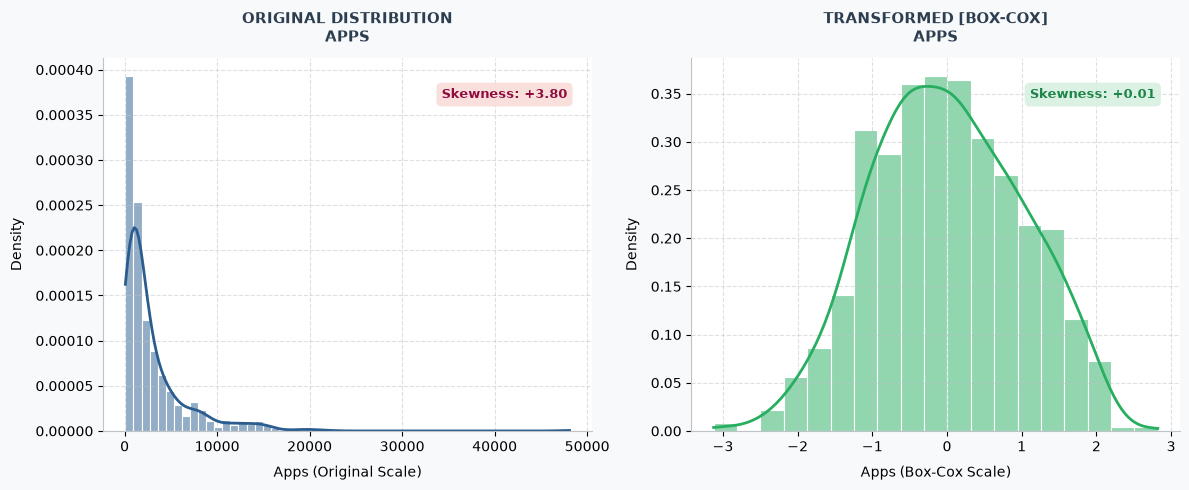

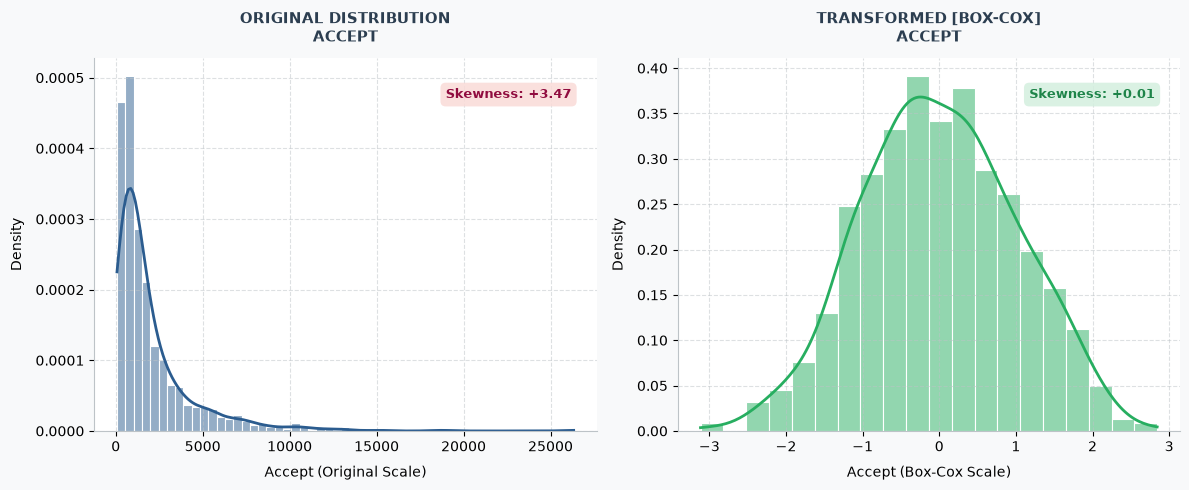

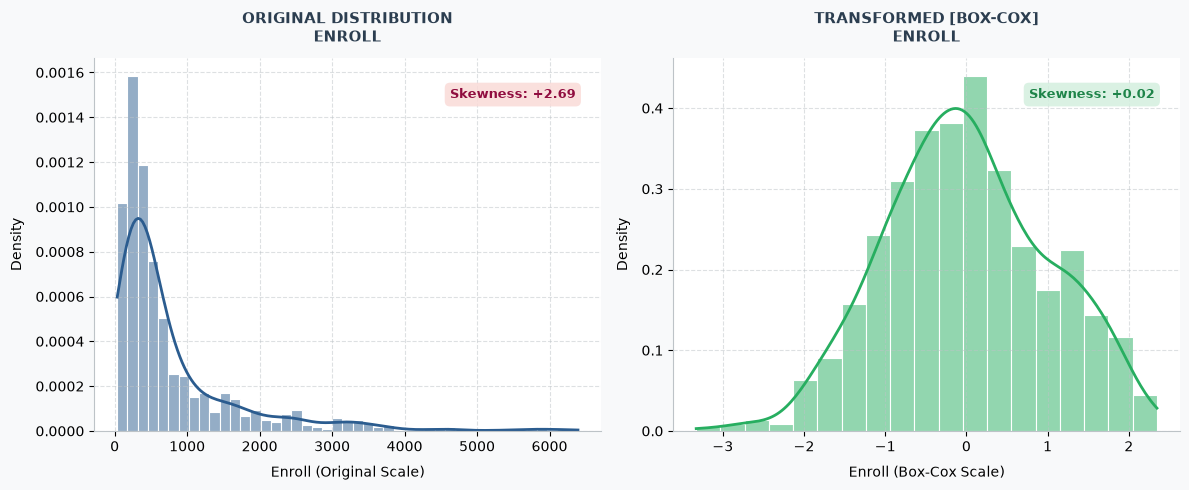

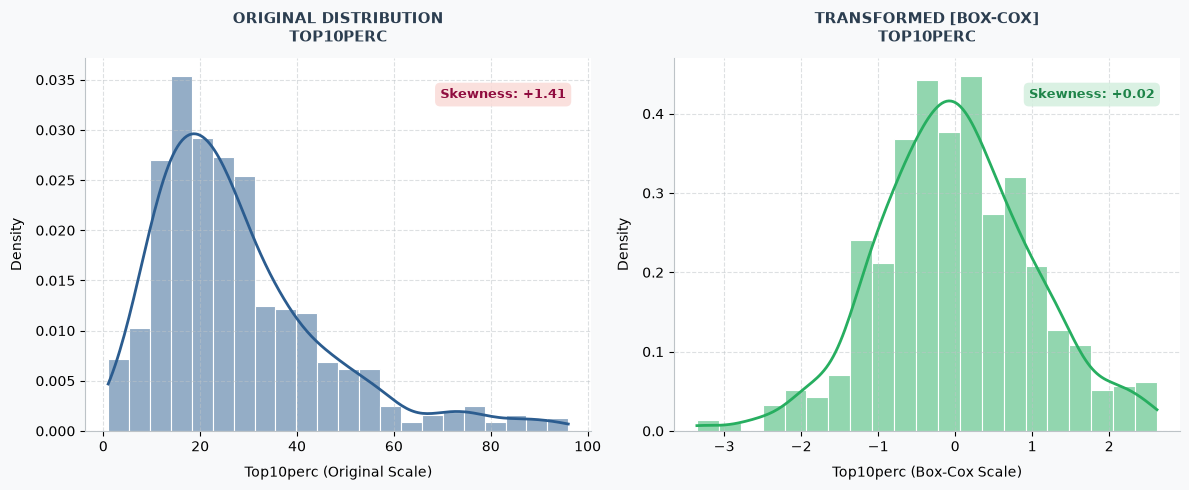

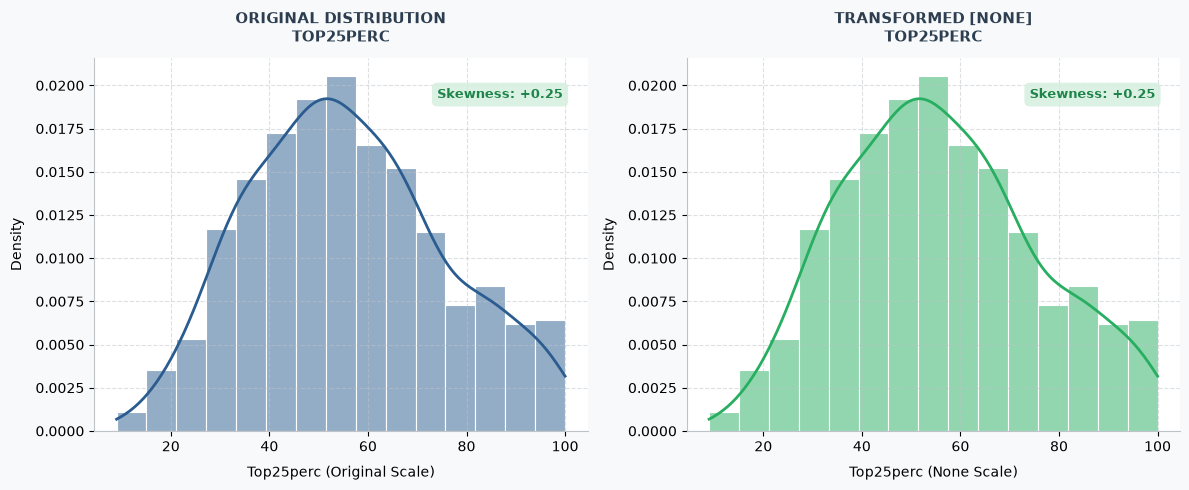

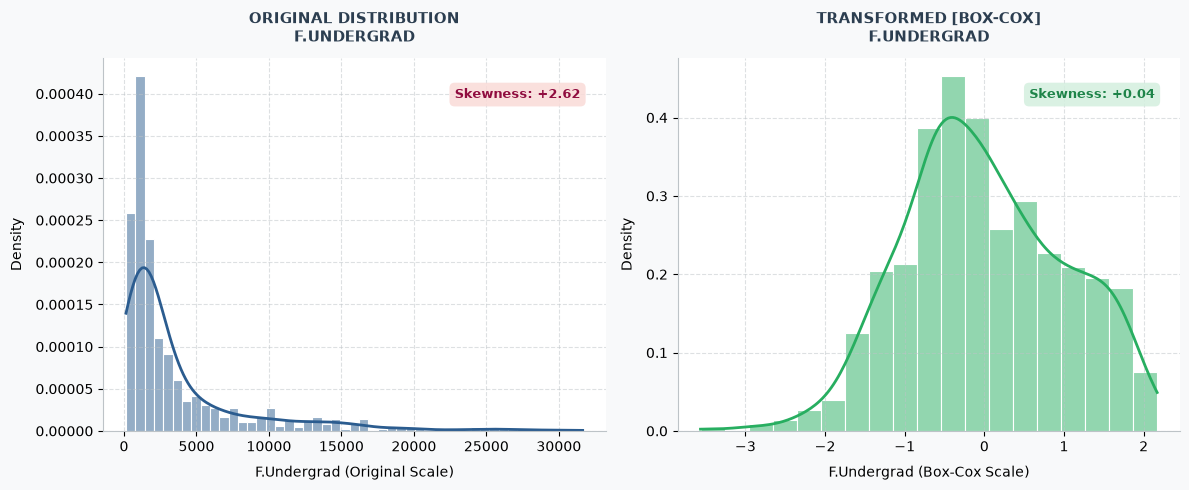

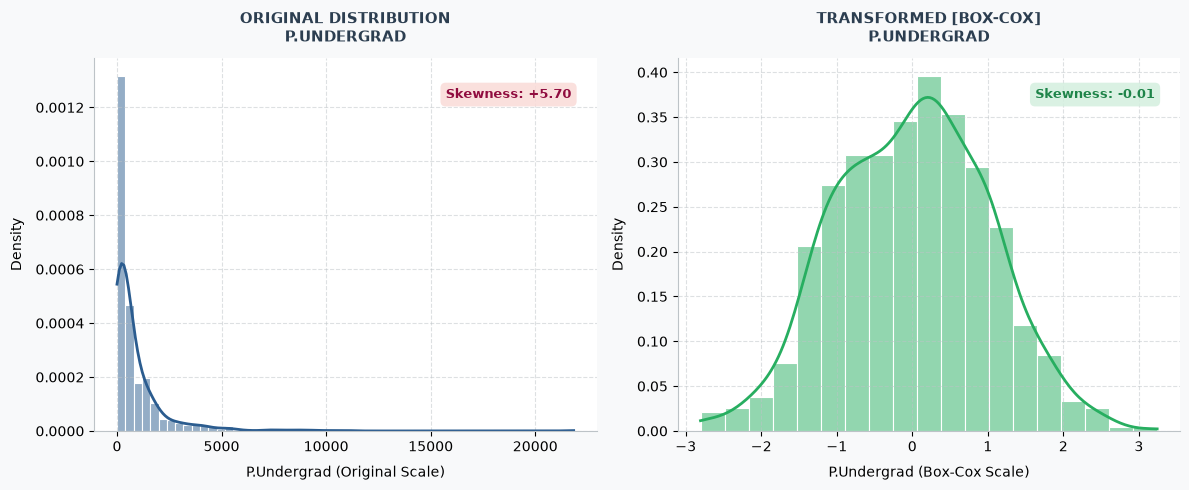

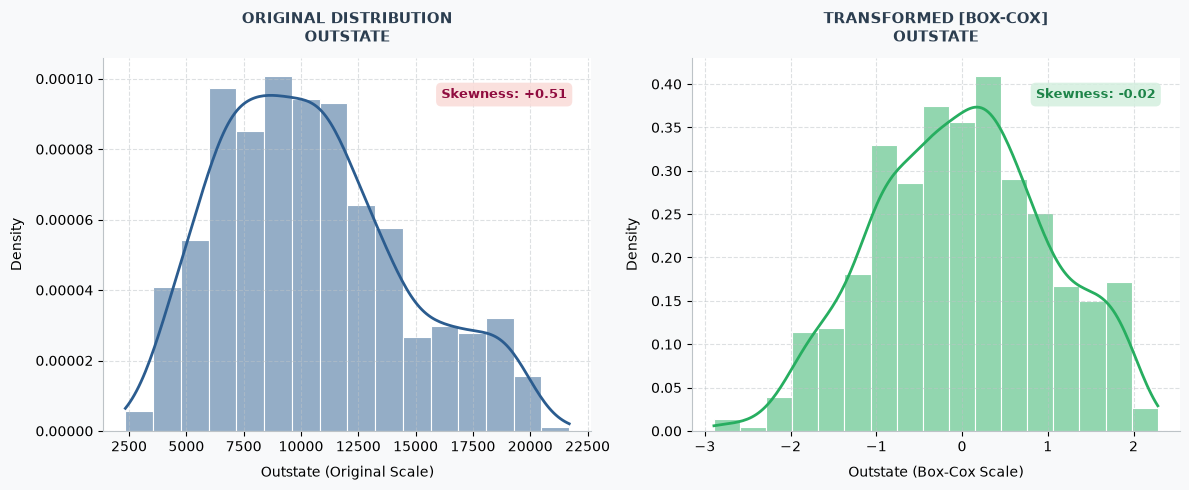

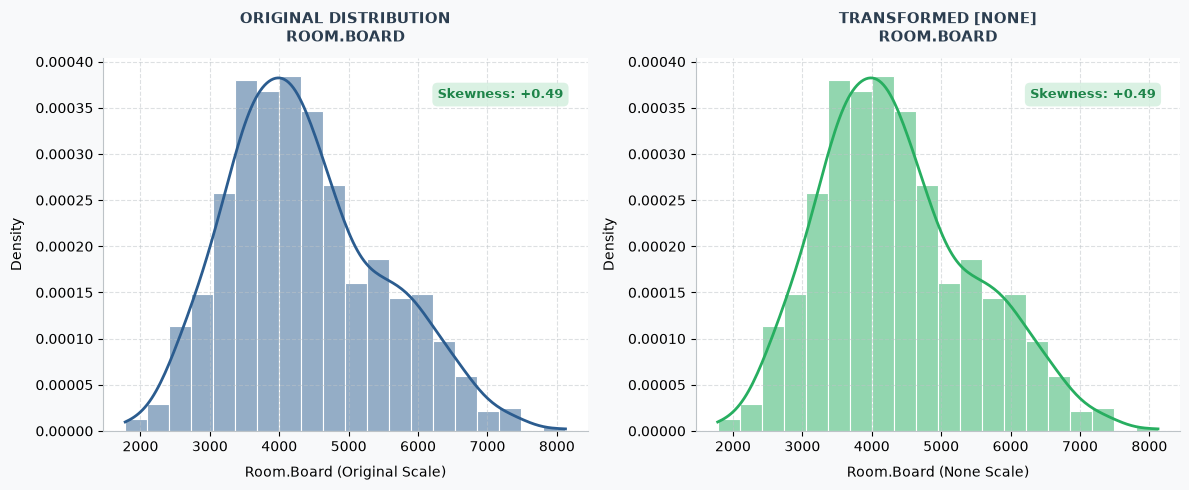

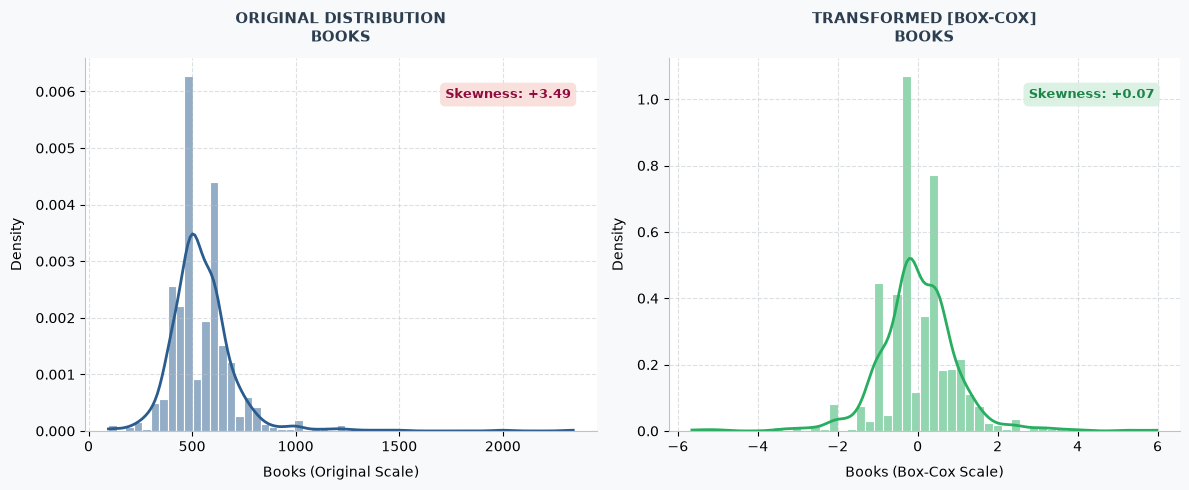

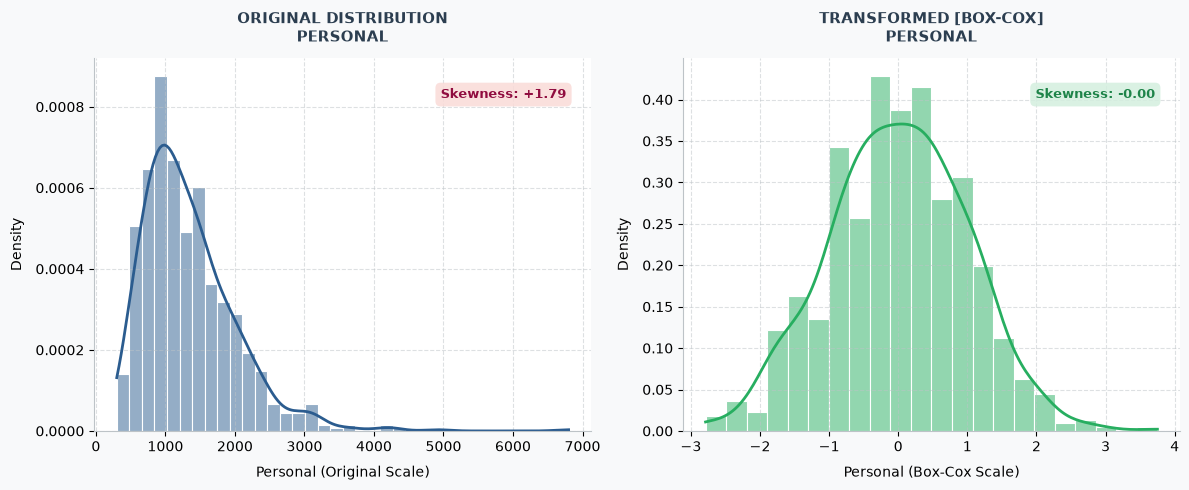

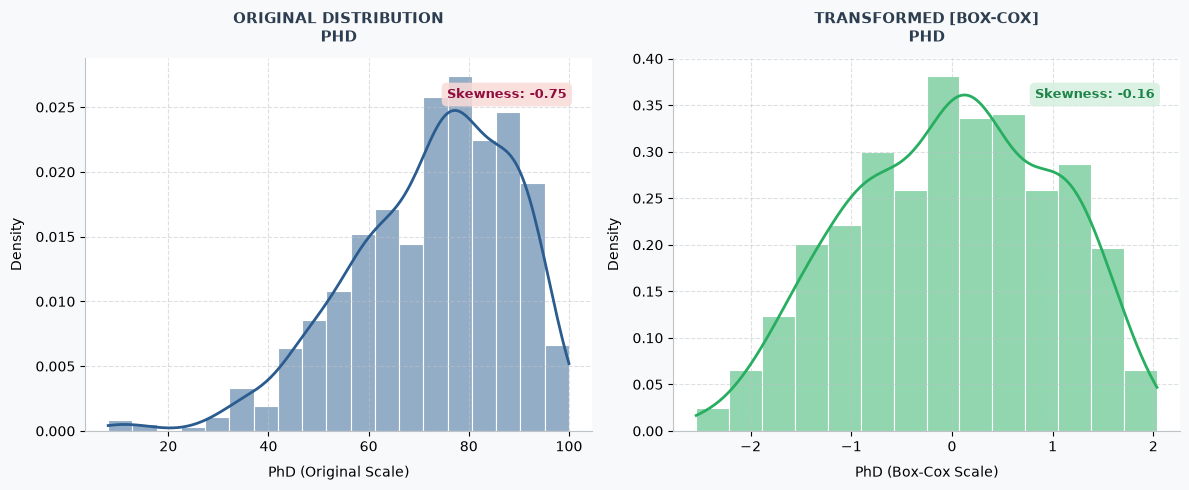

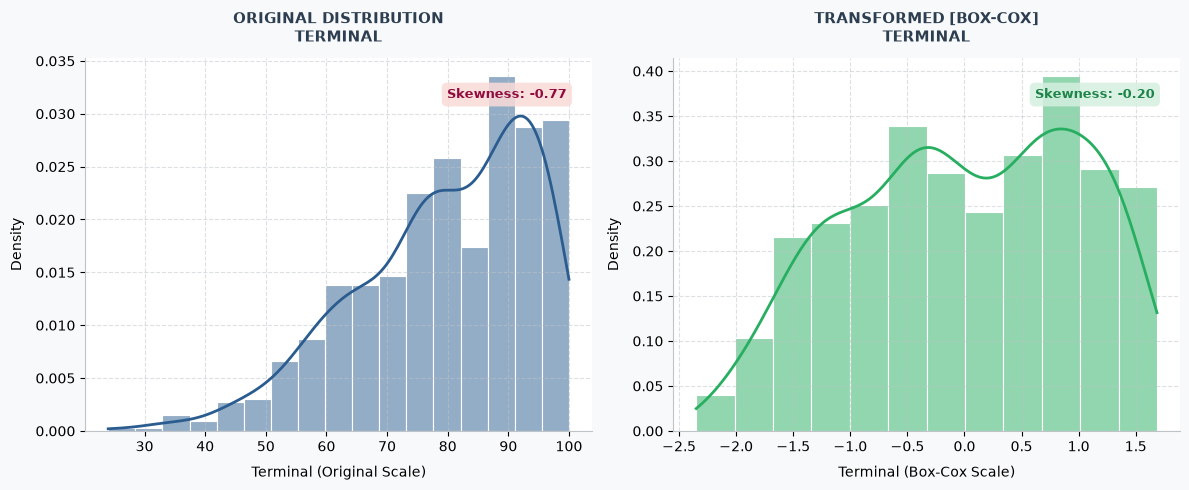

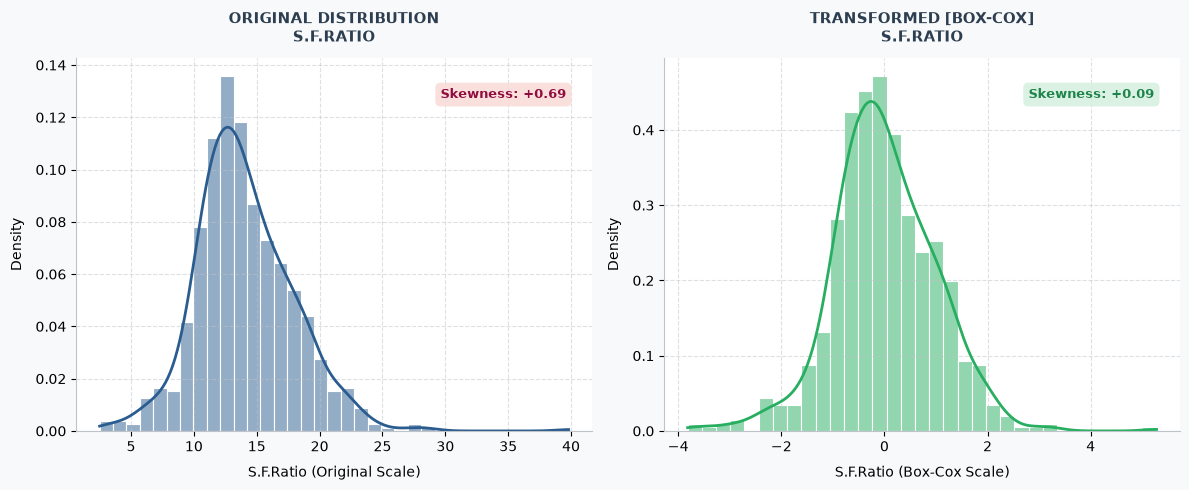

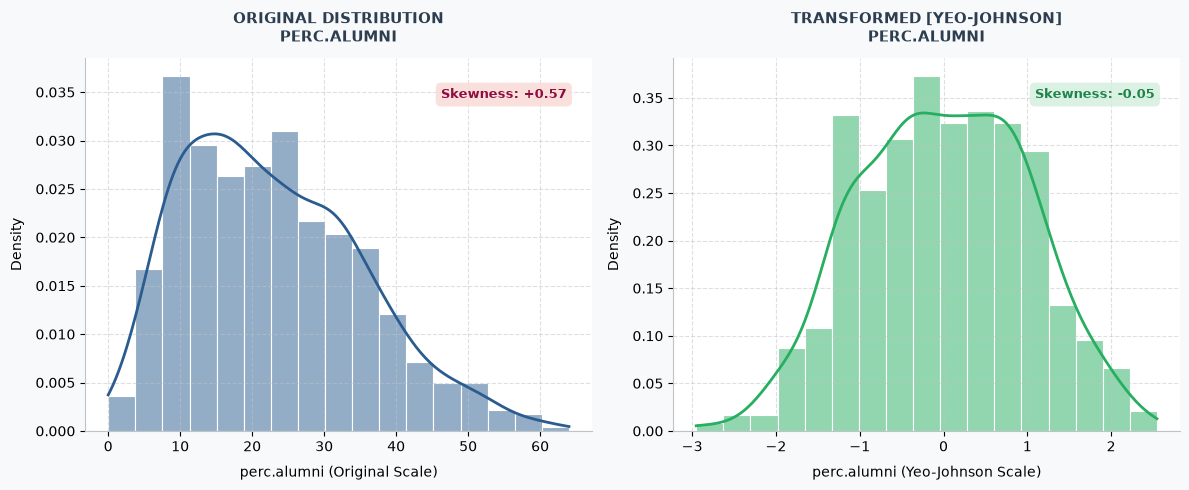

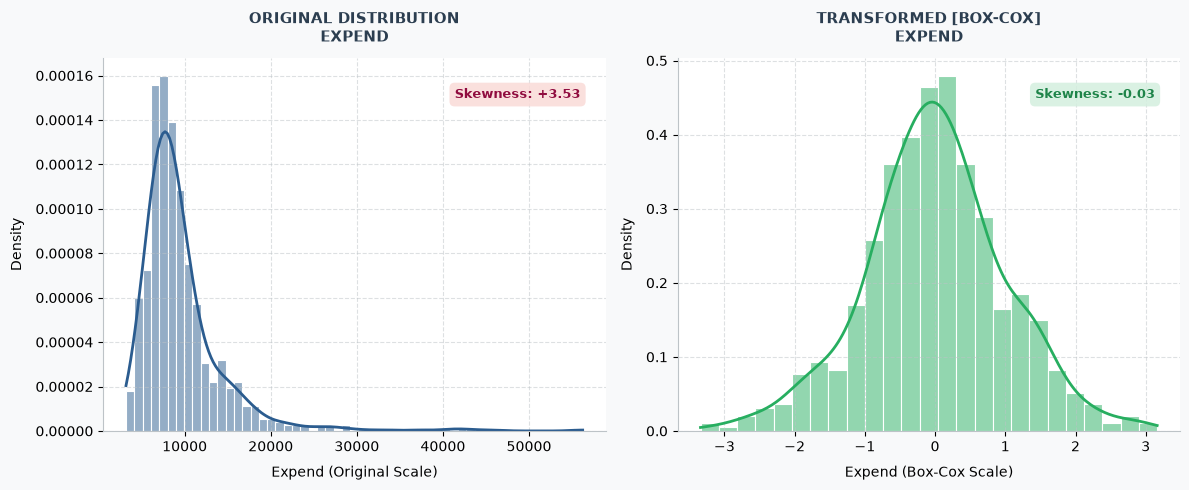

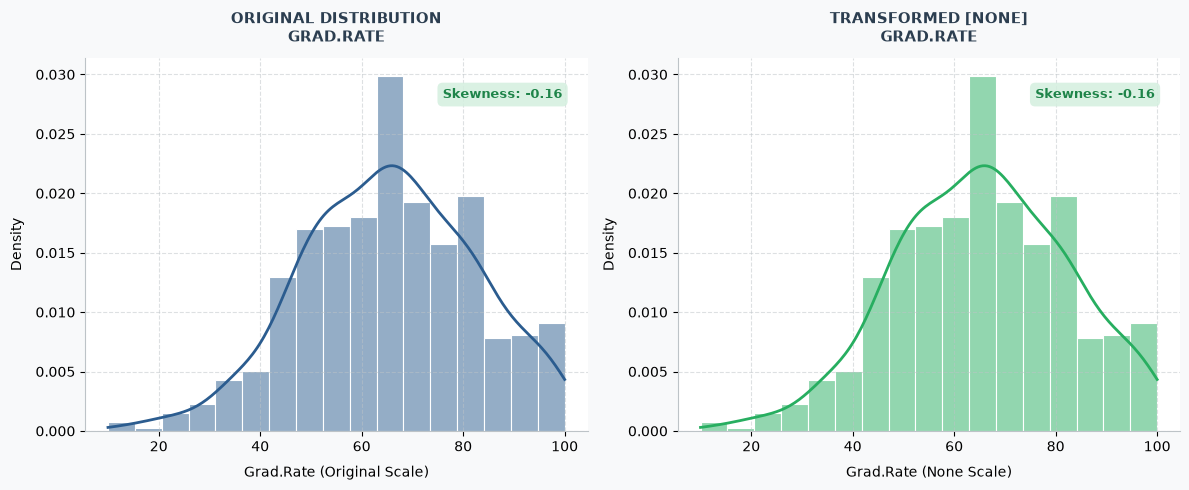

In [86]:
# Your code here
plot_transformations(college,skew)

In [35]:
# Your code here

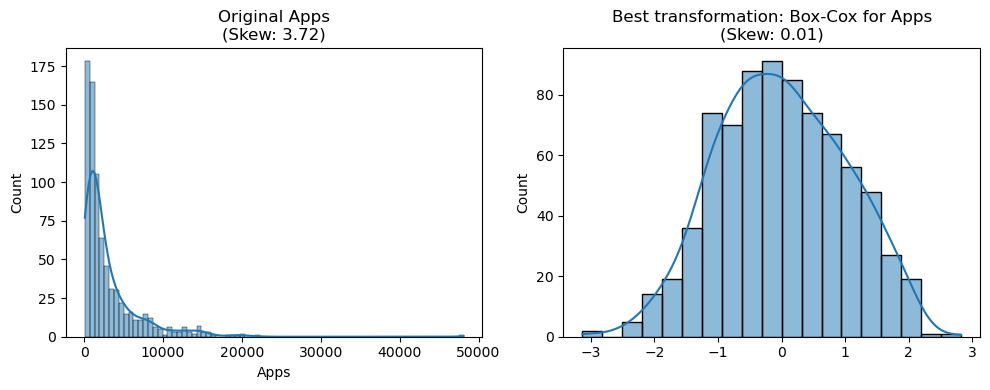

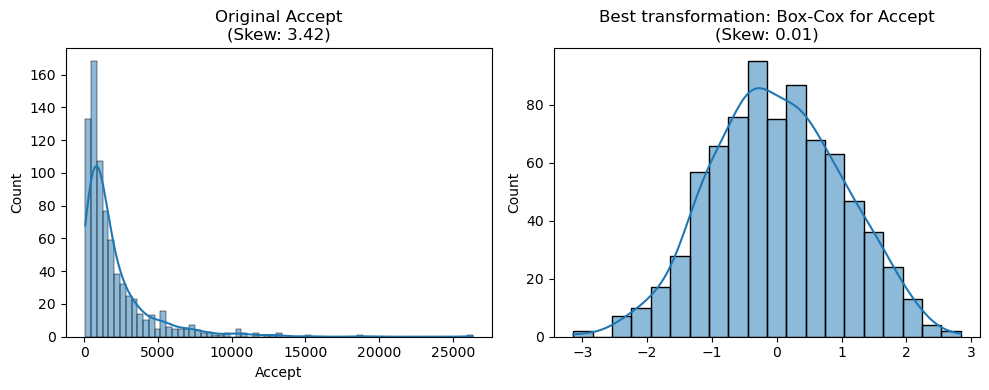

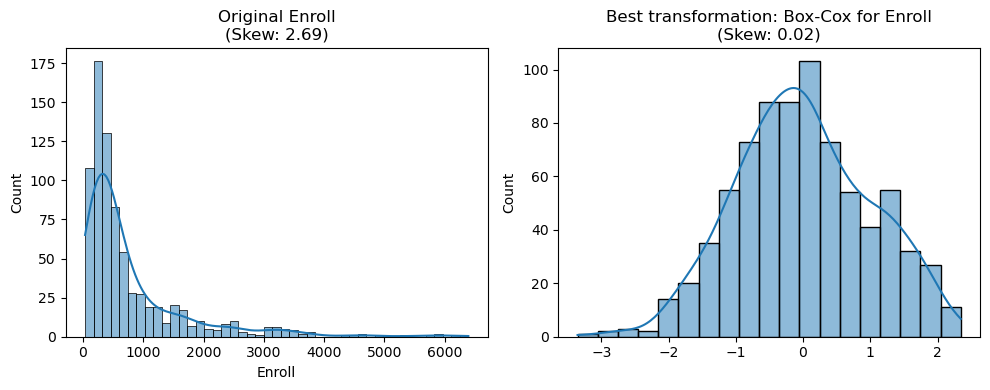

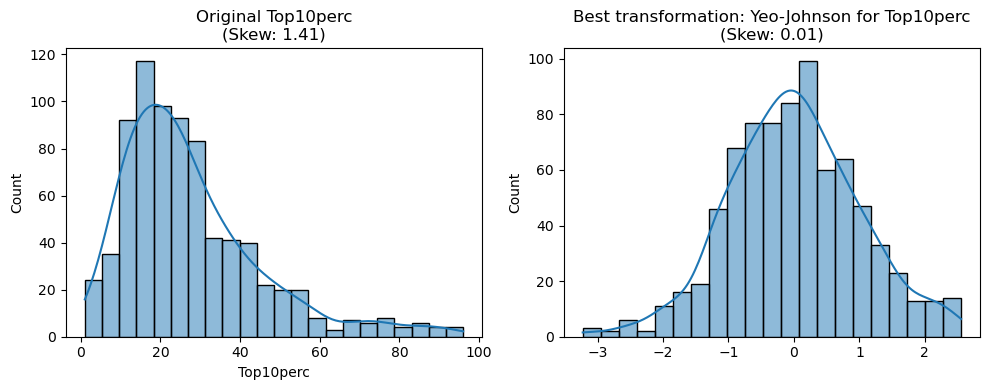

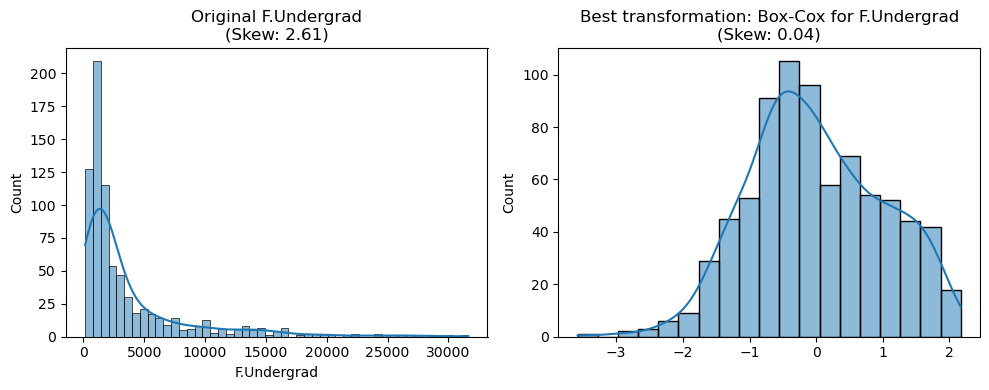

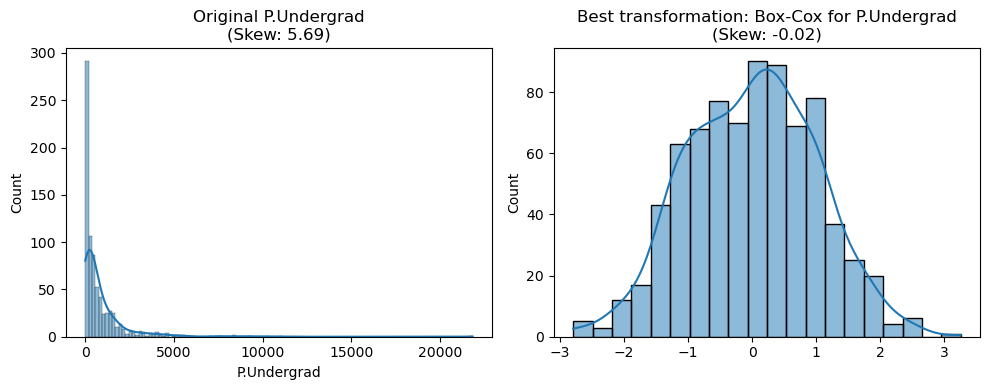

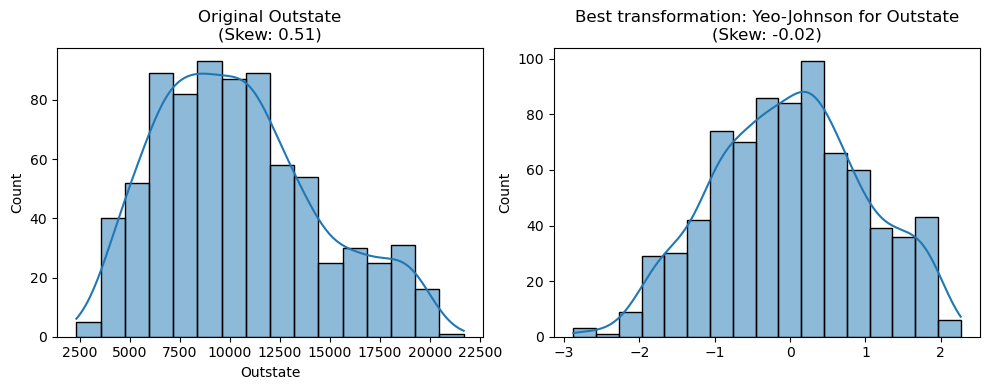

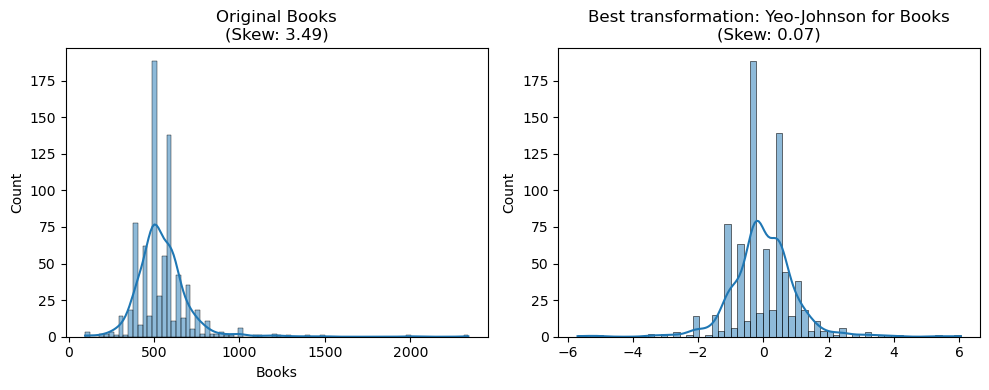

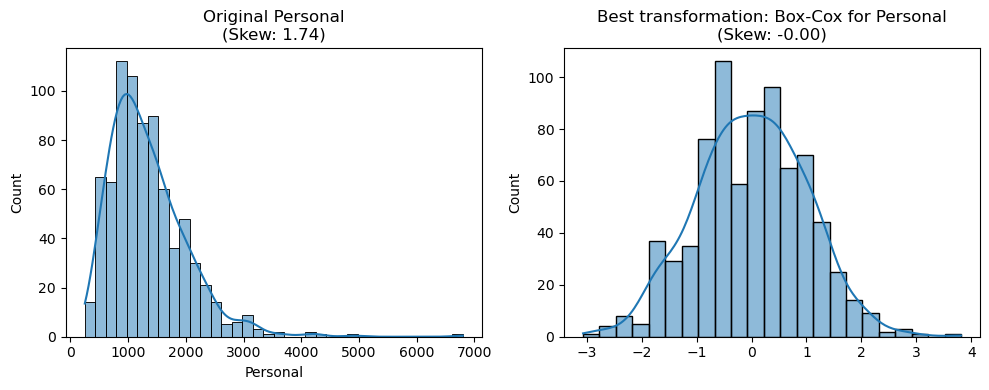

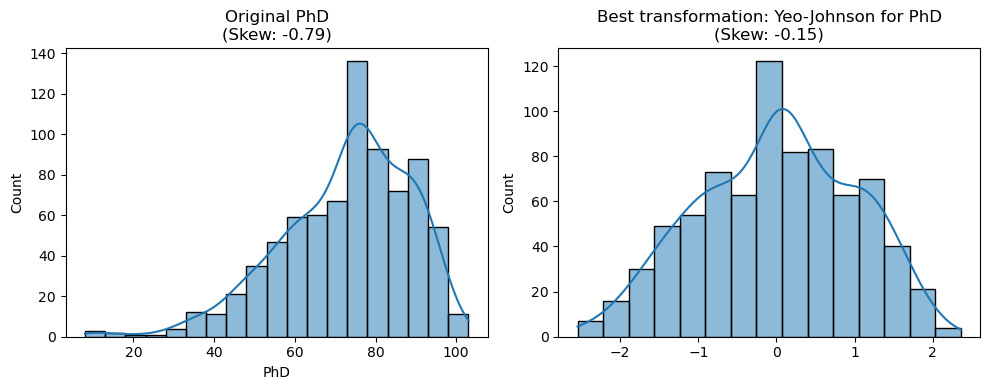

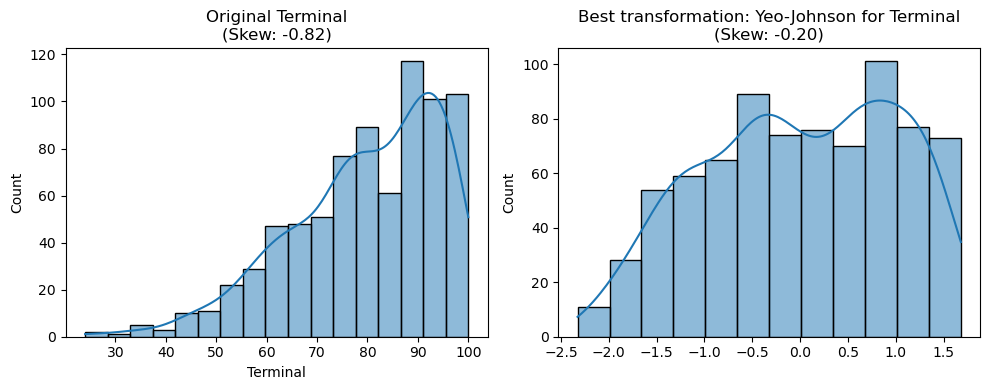

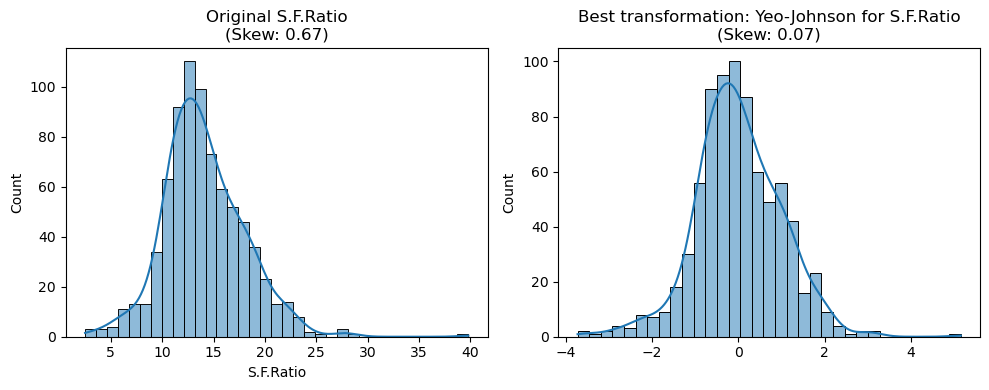

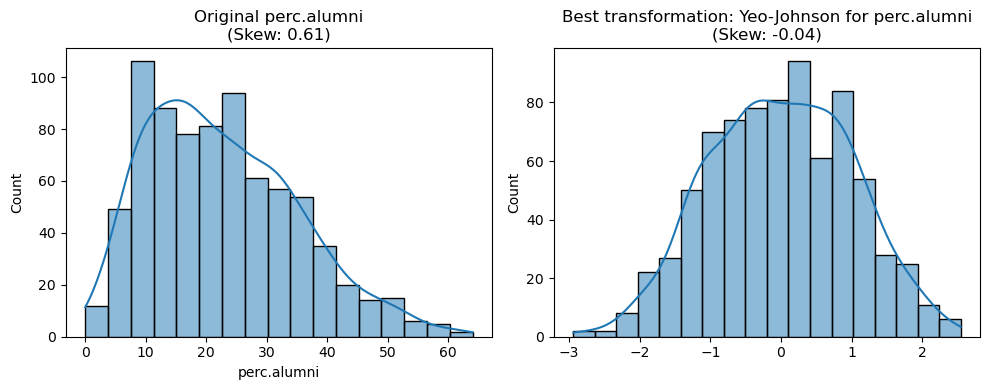

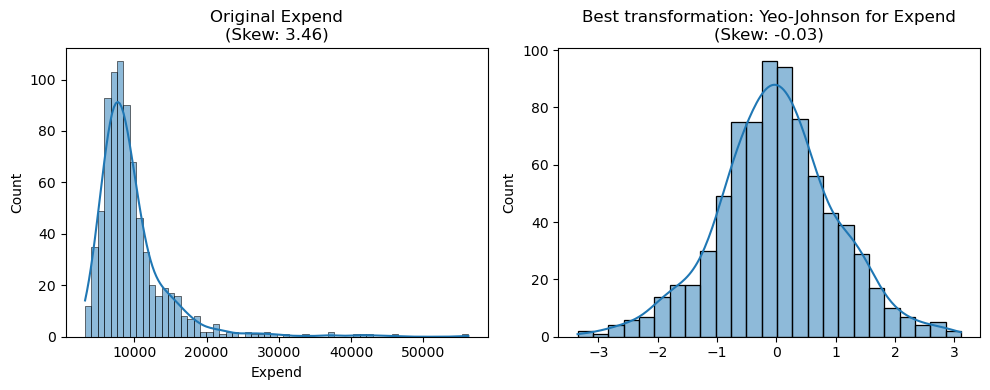

In [ ]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [90]:
trans_cols = []
df=college
skew_table = skew_calc(df)
# Your code here 

for i in range(len(skew_table)):
    row = skew_table.iloc[i]
    feature_name = row["Feature"]
    rec = row["Recommended_Transformation"]

    if rec != "None":
        new_col_name = f"{feature_name}_trans"

        if rec == "Log Plus One (log(x + 1))":
            df[new_col_name] = np.log1p(df[feature_name])

        elif rec == "Yeo-Johnson":
            pt_yeo = PowerTransformer(method="yeo-johnson")
            df[new_col_name] = pt_yeo.fit_transform(
                df[[feature_name]]
            ).flatten()

        elif rec == "Box-Cox":
            pt_boxcox = PowerTransformer(method="box-cox")
            df[new_col_name] = pt_boxcox.fit_transform(
                df[[feature_name]]
            ).flatten()

        trans_cols.append(new_col_name)

print(trans_cols)

['Apps_trans', 'Accept_trans', 'Enroll_trans', 'Top10perc_trans', 'F.Undergrad_trans', 'P.Undergrad_trans', 'Outstate_trans', 'Books_trans', 'Personal_trans', 'PhD_trans', 'Terminal_trans', 'S.F.Ratio_trans', 'perc.alumni_trans', 'Expend_trans']


In [92]:
college.head(2)

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,F.Undergrad_trans,P.Undergrad_trans,Outstate_trans,Books_trans,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,0.439775,0.300136,-0.696383,-0.603674,1.271162,-0.281353,-0.273401,1.037437,-0.848046,-0.489117
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,0.371826,0.867782,0.562796,1.291941,0.460227,-2.165157,-2.268455,-0.437670,-0.444582,0.559834


## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [93]:
# Your code here 
college["Accept_Rate"] = college["Accept"] / college["Apps"]
college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,P.Undergrad_trans,Outstate_trans,Books_trans,Personal_trans,PhD_trans,Terminal_trans,S.F.Ratio_trans,perc.alumni_trans,Expend_trans,Accept_Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,0.300136,-0.696383,-0.603674,1.271162,-0.281353,-0.273401,1.037437,-0.848046,-0.489117,0.742169
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,0.867782,0.562796,1.291941,0.460227,-2.165157,-2.268455,-0.437670,-0.444582,0.559834,0.880146
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,-0.728686,0.326712,-1.023704,-0.066725,-1.244202,-1.036884,-0.249749,0.666643,0.100759,0.768207
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,-0.976269,0.711617,-0.603674,-0.655784,1.341403,1.372885,-1.768466,1.120255,1.748820,0.836930
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,0.625246,-0.659443,1.540240,0.460227,0.119250,-0.680249,-0.519511,-2.343308,0.645230,0.756477


#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [94]:
# Your code here 
college["Outstate_Tier"] = pd.cut(
    college["Outstate"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

# Display value counts to verify
print(college["Outstate_Tier"].value_counts())

Outstate_Tier
Medium    352
Low       290
High      104
Name: count, dtype: int64


#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [95]:
# Your code here 
# Define ordinal mapping dictionary
tier_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

# Map tiers to ordinal integers in a new column
college["Outstate_Tier_Encoded"] = college["Outstate_Tier"].map(tier_mapping)

# Verify mapping
college[["Outstate_Tier", "Outstate_Tier_Encoded"]].head()

,Outstate_Tier,Outstate_Tier_Encoded
0,Low,0
1,Medium,1
2,Medium,1
3,Medium,1
4,Low,0


#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [96]:
# Your code here 
college["Private_Encoded"] = college["Private"].replace({"Yes": 1, "No": 0})

college[["Private", "Private_Encoded"]].head()

,Private,Private_Encoded
0,Yes,1
1,Yes,1
2,Yes,1
3,Yes,1
4,Yes,1


## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [97]:
cols_to_scale = []

cols_to_scale = trans_cols + [
    "Accept_Rate",
    "Outstate_Tier_Encoded",
    "Private_Encoded",
]

scaler = StandardScaler()

scaled_cols = [f"{col}_scaled" for col in cols_to_scale]

college[scaled_cols] = scaler.fit_transform(college[cols_to_scale])

college[scaled_cols].head()


,Apps_trans_scaled,Accept_trans_scaled,Enroll_trans_scaled,Top10perc_trans_scaled,F.Undergrad_trans_scaled,P.Undergrad_trans_scaled,Outstate_trans_scaled,Books_trans_scaled,Personal_trans_scaled,PhD_trans_scaled,Terminal_trans_scaled,S.F.Ratio_trans_scaled,perc.alumni_trans_scaled,Expend_trans_scaled,Accept_Rate_scaled,Outstate_Tier_Encoded_scaled,Private_Encoded_scaled
0,0.040312,0.051276,0.500506,-0.055480,0.439775,0.300136,-0.696383,-0.603674,1.271162,-0.281353,-0.273401,1.037437,-0.848046,-0.489117,-0.037560,-1.099672,0.611432
1,0.294841,0.494913,0.150852,-0.589737,0.371826,0.867782,0.562796,1.291941,0.460227,-2.165157,-2.268455,-0.437670,-0.444582,0.559834,0.912025,0.365248,0.611432
2,-0.101120,-0.066461,-0.305288,-0.123688,-0.626780,-0.728686,0.326712,-1.023704,-0.066725,-1.244202,-1.036884,-0.249749,0.666643,0.100759,0.141642,0.365248,0.611432
3,-1.319091,-1.279698,-1.380517,1.627298,-1.518586,-0.976269,0.711617,-0.603674,-0.655784,1.341403,1.372885,-1.768466,1.120255,1.748820,0.614606,0.365248,0.611432
4,-2.140223,-2.268573,-2.636735,-0.589737,-2.573730,0.625246,-0.659443,1.540240,0.460227,0.119250,-0.680249,-0.519511,-2.343308,0.645230,0.060910,-1.099672,0.611432


#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

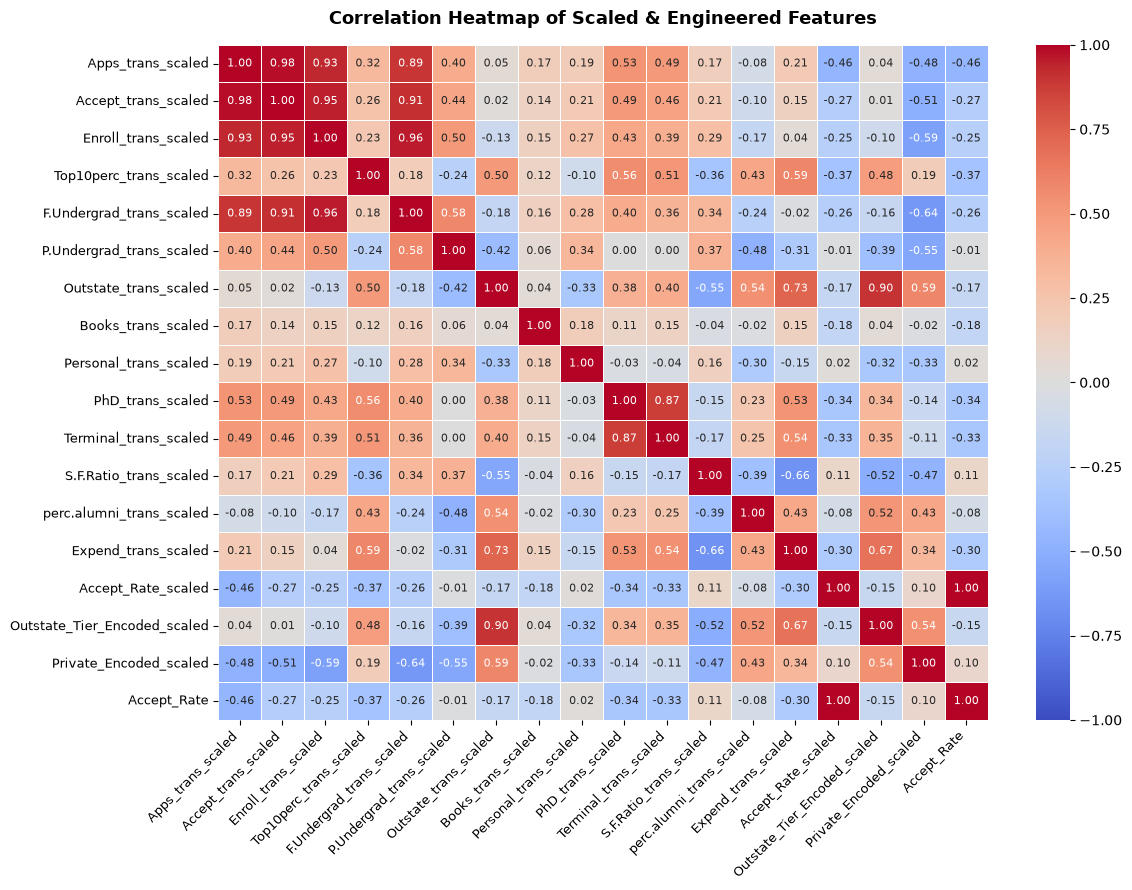

In [100]:
final_cols = scaled_cols + [
    "Accept_Rate"
]

corr_matrix = college[final_cols].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,  
    fmt=".2f",
    annot_kws={"size": 8}, 
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)

plt.title(
    "Correlation Heatmap of Scaled & Engineered Features",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [101]:

duplicates_to_drop = ["Accept_Rate", "Outstate_Tier_Encoded", "Private_Encoded"]
college_cleaned = college.drop(
    columns=[c for c in duplicates_to_drop if c in college.columns],
    errors="ignore",
)

numeric_df = college_cleaned.select_dtypes(include="number")
corr_matrix = numeric_df.corr().abs()

upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_cols = [
    col for col in upper_tri.columns if any(upper_tri[col] > 0.85)
]

print("Features dropped due to high correlation (> 0.85):")
print(high_corr_cols)

college_final = college_cleaned.drop(columns=high_corr_cols)

print(f"\nRemaining features count: {college_final.shape[1]}")

Features dropped due to high correlation (> 0.85):
['Accept', 'Enroll', 'Top25perc', 'F.Undergrad', 'Accept_trans', 'Enroll_trans', 'Top10perc_trans', 'F.Undergrad_trans', 'Outstate_trans', 'Books_trans', 'Personal_trans', 'PhD_trans', 'Terminal_trans', 'S.F.Ratio_trans', 'perc.alumni_trans', 'Expend_trans', 'Apps_trans_scaled', 'Accept_trans_scaled', 'Enroll_trans_scaled', 'Top10perc_trans_scaled', 'F.Undergrad_trans_scaled', 'P.Undergrad_trans_scaled', 'Outstate_trans_scaled', 'Books_trans_scaled', 'Personal_trans_scaled', 'PhD_trans_scaled', 'Terminal_trans_scaled', 'S.F.Ratio_trans_scaled', 'perc.alumni_trans_scaled', 'Expend_trans_scaled', 'Outstate_Tier_Encoded_scaled']

Remaining features count: 20


In [109]:
college_final.corr(numeric_only=True)['Grad.Rate']

Apps                      0.128806
Top10perc                 0.492889
P.Undergrad              -0.261602
Outstate                  0.569771
Room.Board                0.417681
Books                     0.001940
Personal                 -0.269481
PhD                       0.310978
Terminal                  0.290207
S.F.Ratio                -0.292598
perc.alumni               0.483283
Expend                    0.381076
Grad.Rate                 1.000000
Apps_trans                0.183207
P.Undergrad_trans        -0.273266
Accept_Rate_scaled       -0.274453
Private_Encoded_scaled    0.341793
Name: Grad.Rate, dtype: float64

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [104]:
# Your code here 
X= college_final[['Outstate_Tier_Encoded', 'Expend_trans_scaled', 'Top10perc_trans_scaled', 'perc.alumni_trans_scaled']]
y= college_final['Grad.Rate']
X2= college[['Outstate', 'Expend', 'Top10perc', 'perc.alumni']]


X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.25,random_state=1)
X2_train, X2_test, y_train, y_test = train_test_split(X2,y,test_size = 0.25,random_state=1)

lr = LinearRegression()

KeyError: "None of [Index(['Outstate_Tier_Encoded', 'Expend_trans_scaled',\n       'Top10perc_trans_scaled', 'perc.alumni_trans_scaled'],\n      dtype='str')] are in the [columns]"

#### 15. Fit a linear regression using the raw predictors


In [45]:
untrans_predictors = []

# Your code here 

#### 16. Fit the same model using the log-transformed predictors

In [46]:
trans_predictors = []

# Your code here 

#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [47]:
# Your code here 

#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [48]:
# Your code here 